# Weighted rating and simulated attack

Compare the plain average with the weighted rating, then test both against a mass-rating attack: bots post many ratings at once, but nobody marks their reviews as helpful (0 votes), so each bot gets the minimum weight of 0.1.

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

from data_cleaning import load_and_clean
from simulation import compare_ratings, simulate_attack

df = load_and_clean()

Loaded 2961 rows, kept 2761 with a valid rating, (200 dropped).


## Plain vs weighted rating (real reviews)

In [23]:
pd.Series(compare_ratings(df)).round(2)

plain       8.85
weighted    8.92
dtype: float64

On the real reviews the two ratings are almost the same (**8.85** vs **8.92**): the weighting does not change honest opinion much.

## Attack: fake 1-star reviews ("haters")

In [24]:
haters = simulate_attack(df, sizes=[0, 100, 500, 1000, 2000], rating=1)
haters.round(2)

,plain,weighted,plain_change,weighted_change,improvement_%
fake_reviews,,,,,
0,8.85,8.92,0.00,0.00,NaN
100,8.57,8.80,-0.27,-0.11,59.15
500,7.64,8.39,-1.20,-0.53,55.93
1000,6.76,7.92,-2.09,-0.99,52.37
2000,5.55,7.15,-3.30,-1.77,46.43


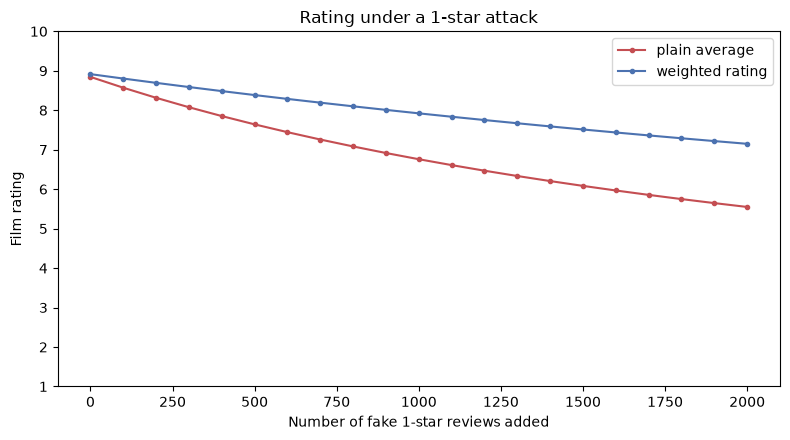

In [28]:
curve = simulate_attack(df, sizes=range(0, 2001, 100), rating=1)

ax = curve.plot(figsize=(8, 4.5), color=["#C44E52", "#4C72B0"], marker="o", markersize=3)
ax.set_xlabel("Number of fake 1-star reviews added")
ax.set_ylabel("Film rating")
ax.set_ylim(1, 10)
ax.set_title("Rating under a 1-star attack")
ax.legend(["plain average", "weighted rating"])
ax.figure.tight_layout()
plt.show()

`plain_change` and `weighted_change` are how far each rating moved from its value without fake reviews; `improvement_%` is how much less the weighted rating moved.

- **500 fake 1s** pull the plain average down by **1.20** (8.85 → 7.64) but the weighted rating by only **0.53** (8.92 → 8.39) – a **56% improvement**.
- The improvement is **59%** for 100 bots and falls to **46%** for 2,000 bots: each bot counts as 0.1 of a person, but enough of them still add up.
- The effect is reduced, not removed.

## Attack: fake 10-star reviews ("fans")

In [26]:
fans = simulate_attack(df, sizes=[0, 100, 500, 1000, 2000], rating=10)
fans.round(2)

,plain,weighted,plain_change,weighted_change,improvement_%
fake_reviews,,,,,
0,8.85,8.92,0.00,0.00,NaN
100,8.89,8.93,0.04,0.02,61.97
500,9.02,8.99,0.18,0.07,58.97
1000,9.15,9.05,0.31,0.14,55.65
2000,9.33,9.16,0.49,0.24,50.12


The same holds for a fan attack: 500 fake 10s raise the plain average by 0.18 and the weighted rating by 0.07 – a **59% improvement** (62% for 100 bots, 50% for 2,000). The changes are small in both cases because the film's rating is already close to 10.

## Limitations

- **Helpfulness votes can be faked too.** Bots that mark each other's reviews as helpful would gain weight. The data does not say who cast the votes, so this cannot be detected here.
- **New honest reviews start at the minimum weight** until readers vote on them.
- **"Helpful" often means "I agree".** For a well-liked film, negative reviews get voted down, so the weighting leans towards the majority opinion.